# Latent Depth Analysis

In [28]:
%matplotlib inline
from IPython.display import display
from collections import Counter
import json
import math
from pathlib import Path
import re
import statistics

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [29]:

ROOT_CANDIDATES = [Path.cwd(), Path.cwd().parent, Path("/home/csalt/Haider/DVLM/lvar")]
ROOT = next((p.resolve() for p in ROOT_CANDIDATES if (p / "outputs/inference/validation_oracle").exists()), None)
if ROOT is None:
    raise FileNotFoundError("Could not locate repo root containing outputs/inference/validation_oracle")


In [30]:
# IVT-LR
IVTLR_M3COT_VALIDATION = Path(
    "/home/csalt/Haider/DVLM/IVT-LR/qwen_vl/output/inference/m3cot_validation/inference/m3cot"
)

IVTLR_M3COT_TEST = Path(
    "/home/csalt/Haider/DVLM/IVT-LR/qwen_vl/output/inference/m3cot/inference/m3cot"
)


# LVAR
LVAR_M3COT_VALIDATION = Path(
    "/home/csalt/Haider/DVLM/IVT-LR/qwen_vl/outputs_lvar/inference/m3cot"
)
LVAR_M3COT_TEST = Path(
    "/home/csalt/Haider/DVLM/IVT-LR/qwen_vl/outputs_dynamic_ivtlr/inference/m3cot"
)


LOG_NAME = "qwen_m3cot_infer_stdout_stderr.log"
FINAL_RESULT_RE = re.compile(
    r"\[FINAL\]\s+Total:\s*(?P<total>\d+),\s*"
    r"Correct:\s*(?P<correct>\d+),\s*"
    r"Accuracy:\s*(?P<accuracy>[0-9]+(?:\.[0-9]+)?)%"
)

In [31]:
# IVT-LR ScienceQA
IVTLR_SQA_VALIDATION = Path(
    "/home/csalt/Haider/DVLM/IVT-LR/qwen_vl/output/inference/sqa_validation/inference/sqa"
)

IVTLR_SQA_TEST = Path(
    "/home/csalt/Haider/DVLM/IVT-LR/qwen_vl/output/inference/sqa/inference/sqa"
)

# LVAR ScienceQA
LVAR_SQA_VALIDATION = Path(
    "/home/csalt/Haider/DVLM/IVT-LR/qwen_vl/outputs_lvar_sqa_validation/inference/sqa"
)
LVAR_SQA_TEST = Path(
    "/home/csalt/Haider/DVLM/IVT-LR/qwen_vl/outputs_lvar_sqa/inference/sqa"
)
SQA_LOG_NAME = "qwen_scienceqa_infer_stdout_stderr.log"

## Helpers

The helpers below normalize naming across paths, load JSONL safely, and derive trace-level metrics from both high-level decisions and primitive trace actions.

In [32]:
def load_json(path):
    path = Path(path)
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def load_jsonl(path):
    path = Path(path)
    rows = []
    bad_rows = []
    with path.open("r", encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            stripped = line.strip()
            if not stripped:
                continue
            try:
                rows.append(json.loads(stripped))
            except json.JSONDecodeError as exc:
                bad_rows.append({
                    "path": str(path),
                    "line_number": line_number,
                    "error": str(exc),
                    "context": stripped[max(0, exc.pos - 100): exc.pos + 100],
                })
    return rows, bad_rows


ANSWER_PATTERNS = [
    re.compile(r"(?:answer|option|choice)\s*(?:is|:|=)?\s*[\(\[]?([A-D])\b", re.IGNORECASE),
    re.compile(r"\b([A-D])\s*(?:is|would be)\s*(?:the\s*)?(?:correct\s*)?(?:answer|option|choice)\b", re.IGNORECASE),
]


def normalize_answer(value):
    if value is None:
        return None
    match = re.search(r"\b([A-D])\b", str(value).upper())
    return match.group(1) if match else None


def decoded_response_from_messages(messages):
    if not isinstance(messages, list) or not messages:
        return ""
    return str(messages[-1])


def extract_answer_from_response(response):
    response = str(response or "")
    matches = []
    for pattern in ANSWER_PATTERNS:
        matches.extend(match.group(1).upper() for match in pattern.finditer(response))
    if matches:
        return matches[-1]

    standalone = re.findall(r"(?<![A-Z])([A-D])(?![A-Z])", response.upper())
    return standalone[-1] if standalone else None


def clean_ckpt_name(value):
    if value is None:
        return None
    value = str(value)
    value = value.replace("mined_by_", "").replace("evaluated_by_", "")
    value = value.replace("_ckpt", "")
    return value


def pretty_variant(value):
    mapping = {
        "raw": "raw",
        "filtered_cap": "filtered (cap)",
        "filtered_no_cap": "filtered (no cap)",
    }
    return mapping.get(str(value), str(value))


def parse_inference_summary_path(path):
    parts = Path(path).parts
    mined_by = next((clean_ckpt_name(p) for p in parts if p.startswith("mined_by_")), None)
    evaluated_by = next((clean_ckpt_name(p) for p in parts if p.startswith("evaluated_by_")), None)
    variant_dir = next((p.replace("trace_variant_", "") for p in parts if p.startswith("trace_variant_")), None)
    return mined_by, evaluated_by, variant_dir


def parse_trace_path(path):
    path = Path(path)
    match = re.search(r"m3cot_validation_traces_(?P<mined_by>.+?)_(?P<context>global|coarse)\.jsonl$", path.name)
    mined_by = match.group("mined_by") if match else clean_ckpt_name(path.parent.name)
    context = match.group("context") if match else None
    return clean_ckpt_name(mined_by), context


def parse_mining_and_replay_context(summary, artifact_path):
    trace_path = summary.get("trace_path")
    mining_context = parse_trace_path(trace_path)[1] if trace_path else None
    suffix = re.search(r"_replayed-under_(global|coarse|full_context|global_mean)(?:_|\.)", Path(artifact_path).name)
    replay_context = suffix.group(1) if suffix else mining_context
    return mining_context, replay_context


def action_type(action):
    return str(action.get("type", action.get("action", "UNKNOWN"))).upper()


def action_index(action):
    if "patch_idx" in action:
        return action.get("patch_idx")
    if "patch_index" in action:
        return action.get("patch_index")
    if "region_idx" in action:
        return action.get("region_idx")
    if "region_index" in action:
        return action.get("region_index")
    return None


def decision_reduction(decision):
    if decision.get("improvement") is not None:
        return float(decision.get("improvement"))
    ce_noop = decision.get("ce_noop")
    ce_selected = decision.get("ce_selected")
    if ce_noop is not None and ce_selected is not None:
        return float(ce_noop) - float(ce_selected)
    return np.nan


def finite_mean(values):
    values = [float(v) for v in values if pd.notna(v)]
    return float(np.mean(values)) if values else np.nan


def finite_sum(values):
    values = [float(v) for v in values if pd.notna(v)]
    return float(np.sum(values)) if values else np.nan


def infer_grid_size(indices):
    indices = [int(i) for i in indices if pd.notna(i)]
    if not indices:
        return 1
    return int(math.ceil(math.sqrt(max(indices) + 1)))

def setting_sort_key(setting):
    match = re.fullmatch(r"latent_steps_(\d+)", setting)
    if match:
        return (0, int(match.group(1)))
    if setting == "dynamic_latent_steps":
        return (1, 0)
    return (2, setting)


# M3CoT Test Set

## IVT-LR

In [33]:
rows = []
for log_path in IVTLR_M3COT_TEST.glob(f"*/{LOG_NAME}"):
    matches = list(FINAL_RESULT_RE.finditer(log_path.read_text(errors="replace")))
    if not matches:
        print(f"Warning: no [FINAL] result found in {log_path}")
        continue

    result = matches[-1].groupdict()
    rows.append(
        {
            "setting": log_path.parent.name,
            "total": int(result["total"]),
            "correct": int(result["correct"]),
            "accuracy_pct": float(result["accuracy"]),
        }
    )

if not rows:
    raise RuntimeError(f"No final accuracy results found under {IVTLR_M3COT_TEST}")

ivtlr_m3cot_test_accuracy = (
    pd.DataFrame(rows)
    .sort_values("setting", key=lambda column: column.map(setting_sort_key))
    .reset_index(drop=True)
)
display(
    ivtlr_m3cot_test_accuracy.style
    .format({"accuracy_pct": "{:.2f}%"})
    .hide(axis="index")
)

setting,total,correct,accuracy_pct
original_ivtlr_latent_steps_0,2318,1498,64.62%
original_ivtlr_latent_steps_1,2318,1500,64.71%
original_ivtlr_latent_steps_10,2318,1486,64.11%
original_ivtlr_latent_steps_2,2318,1489,64.24%
original_ivtlr_latent_steps_3,2318,1501,64.75%
original_ivtlr_latent_steps_4,2318,1503,64.84%
original_ivtlr_latent_steps_5,2318,1493,64.41%
original_ivtlr_latent_steps_6,2318,1491,64.32%
original_ivtlr_latent_steps_7,2318,1494,64.45%
original_ivtlr_latent_steps_8,2318,1486,64.11%


In [34]:
M3COT_PREDICTIONS_NAME = "qwen_m3cot_predictions.jsonl"
EXPECTED_LATENT_STEPS = list(range(11))

m3cot_prediction_rows = []
m3cot_bad_prediction_rows = []

for prediction_path in sorted(IVTLR_M3COT_TEST.glob(f"original_ivtlr_latent_steps_*/{M3COT_PREDICTIONS_NAME}")):
    setting = prediction_path.parent.name
    match = re.fullmatch(r"original_ivtlr_latent_steps_(\d+)", setting)
    if not match:
        continue

    latent_steps = int(match.group(1))
    if latent_steps not in EXPECTED_LATENT_STEPS:
        continue

    rows, bad_rows = load_jsonl(prediction_path)
    m3cot_bad_prediction_rows.extend(bad_rows)
    for row in rows:
        decoded_response = decoded_response_from_messages(row.get("messages"))
        gold_answer = normalize_answer(row.get("answer"))
        decoded_answer = extract_answer_from_response(decoded_response)
        m3cot_prediction_rows.append({
            "example_id": row.get("id") or row.get("example_id"),
            "latent_steps": latent_steps,
            "setting": setting,
            "domain": row.get("domain"),
            "topic": row.get("topic"),
            "gold_answer": gold_answer,
            "decoded_answer": decoded_answer,
            "correct": decoded_answer == gold_answer if gold_answer and decoded_answer else False,
            "question": row.get("messages", [None])[0] if row.get("messages") else None,
            "decoded_response": decoded_response,
            "prediction_path": str(prediction_path),
        })

ivtlr_m3cot_test_predictions_extracted = pd.DataFrame(m3cot_prediction_rows)
if ivtlr_m3cot_test_predictions_extracted.empty:
    raise RuntimeError(f"No fixed-step M3CoT prediction rows found under {IVTLR_M3COT_TEST}")

missing_latent_steps = sorted(set(EXPECTED_LATENT_STEPS) - set(ivtlr_m3cot_test_predictions_extracted["latent_steps"].unique()))
if missing_latent_steps:
    print(f"Warning: missing fixed latent-step prediction files for steps: {missing_latent_steps}")
if m3cot_bad_prediction_rows:
    print(f"Warning: {len(m3cot_bad_prediction_rows):,} malformed JSONL rows while loading M3CoT predictions")

ivtlr_m3cot_test_latent_accuracy_extracted = (
    ivtlr_m3cot_test_predictions_extracted
    .groupby(["latent_steps", "setting"], as_index=False)
    .agg(total=("example_id", "nunique"), correct=("correct", "sum"))
    .sort_values("latent_steps")
)
ivtlr_m3cot_test_latent_accuracy_extracted["accuracy_pct"] = 100 * ivtlr_m3cot_test_latent_accuracy_extracted["correct"] / ivtlr_m3cot_test_latent_accuracy_extracted["total"]
display(ivtlr_m3cot_test_latent_accuracy_extracted.style.format({"accuracy_pct": "{:.2f}%"}).hide(axis="index"))


latent_steps,setting,total,correct,accuracy_pct
0,original_ivtlr_latent_steps_0,2318,1477,63.72%
1,original_ivtlr_latent_steps_1,2318,1482,63.93%
2,original_ivtlr_latent_steps_2,2318,1471,63.46%
3,original_ivtlr_latent_steps_3,2318,1483,63.98%
4,original_ivtlr_latent_steps_4,2318,1484,64.02%
5,original_ivtlr_latent_steps_5,2318,1473,63.55%
6,original_ivtlr_latent_steps_6,2318,1472,63.50%
7,original_ivtlr_latent_steps_7,2318,1477,63.72%
8,original_ivtlr_latent_steps_8,2318,1470,63.42%
9,original_ivtlr_latent_steps_9,2318,1470,63.42%


In [35]:
oracle_rows = []
for example_id, group in ivtlr_m3cot_test_predictions_extracted.groupby("example_id", dropna=False):
    group = group.sort_values("latent_steps")
    correct_steps = group.loc[group["correct"], "latent_steps"].astype(int).tolist()
    first = group.iloc[0]
    oracle_rows.append({
        "example_id": example_id,
        "domain": first.get("domain"),
        "topic": first.get("topic"),
        "gold_answer": first.get("gold_answer"),
        "oracle_correct": bool(correct_steps),
        "num_correct_latent_steps": len(correct_steps),
        "correct_latent_steps": correct_steps,
        "ideal_latent_steps": correct_steps[0] if correct_steps else np.nan,
        "question": first.get("question"),
    })

ivtlr_m3cot_test_oracle_by_question = pd.DataFrame(oracle_rows).sort_values(["oracle_correct", "num_correct_latent_steps", "example_id"], ascending=[False, False, True])

correct_wide = (
    ivtlr_m3cot_test_predictions_extracted
    .pivot_table(index="example_id", columns="latent_steps", values="correct", aggfunc="first")
    .rename(columns=lambda step: f"correct_at_step_{step}")
    .reset_index()
)
answer_wide = (
    ivtlr_m3cot_test_predictions_extracted
    .pivot_table(index="example_id", columns="latent_steps", values="decoded_answer", aggfunc="first")
    .rename(columns=lambda step: f"answer_at_step_{step}")
    .reset_index()
)
ivtlr_m3cot_test_oracle_by_question = ivtlr_m3cot_test_oracle_by_question.merge(correct_wide, on="example_id", how="left").merge(answer_wide, on="example_id", how="left")

ivtlr_m3cot_test_oracle_summary = pd.DataFrame([{
    "questions": ivtlr_m3cot_test_oracle_by_question["example_id"].nunique(),
    "oracle_correct": int(ivtlr_m3cot_test_oracle_by_question["oracle_correct"].sum()),
    "oracle_accuracy_pct": 100 * ivtlr_m3cot_test_oracle_by_question["oracle_correct"].mean(),
    "avg_correct_latent_steps_per_question": ivtlr_m3cot_test_oracle_by_question["num_correct_latent_steps"].mean(),
}])

display(ivtlr_m3cot_test_oracle_summary.style.format({
    "oracle_accuracy_pct": "{:.2f}%",
    "avg_correct_latent_steps_per_question": "{:.2f}",
}).hide(axis="index"))

questions,oracle_correct,oracle_accuracy_pct,avg_correct_latent_steps_per_question
2318,1651,71.23%,7.00


## LVAR

In [36]:
rows = []
for log_path in LVAR_M3COT_TEST.glob(f"latent_steps*/{LOG_NAME}"):
    matches = list(FINAL_RESULT_RE.finditer(log_path.read_text(errors="replace")))
    if not matches:
        print(f"Warning: no [FINAL] result found in {log_path}")
        continue

    result = matches[-1].groupdict()
    rows.append(
        {
            "setting": log_path.parent.name,
            "total": int(result["total"]),
            "correct": int(result["correct"]),
            "accuracy_pct": float(result["accuracy"]),
        }
    )

if not rows:
    raise RuntimeError(f"No final accuracy results found under {LVAR_M3COT_TEST}")

lvar_m3cot_test_accuracy = (
    pd.DataFrame(rows)
    .sort_values("setting", key=lambda column: column.map(setting_sort_key))
    .reset_index(drop=True)
)
display(
    lvar_m3cot_test_accuracy.style
    .format({"accuracy_pct": "{:.2f}%"})
    .hide(axis="index")
)

setting,total,correct,accuracy_pct
latent_steps_0,2318,1401,60.44%
latent_steps_1,2318,1474,63.59%
latent_steps_2,2318,1455,62.77%
latent_steps_3,2318,1459,62.94%
latent_steps_4,2318,1456,62.81%
latent_steps_5,2318,1443,62.25%
latent_steps_6,2318,1452,62.64%
latent_steps_7,2318,1446,62.38%
latent_steps_8,2318,1435,61.91%
latent_steps_9,2318,1435,61.91%


In [37]:
M3COT_PREDICTIONS_NAME = "qwen_m3cot_predictions.jsonl"
EXPECTED_LATENT_STEPS = list(range(11))

m3cot_prediction_rows = []
m3cot_bad_prediction_rows = []

for prediction_path in sorted(LVAR_M3COT_TEST.glob(f"latent_steps*/{M3COT_PREDICTIONS_NAME}")):
    setting = prediction_path.parent.name
    match = re.fullmatch(r"latent_steps_(\d+)", setting)
    if not match:
        continue

    latent_steps = int(match.group(1))
    if latent_steps not in EXPECTED_LATENT_STEPS:
        continue

    rows, bad_rows = load_jsonl(prediction_path)
    m3cot_bad_prediction_rows.extend(bad_rows)
    for row in rows:
        decoded_response = decoded_response_from_messages(row.get("messages"))
        gold_answer = normalize_answer(row.get("answer"))
        decoded_answer = extract_answer_from_response(decoded_response)
        m3cot_prediction_rows.append({
            "example_id": row.get("id") or row.get("example_id"),
            "latent_steps": latent_steps,
            "setting": setting,
            "domain": row.get("domain"),
            "topic": row.get("topic"),
            "gold_answer": gold_answer,
            "decoded_answer": decoded_answer,
            "correct": decoded_answer == gold_answer if gold_answer and decoded_answer else False,
            "question": row.get("messages", [None])[0] if row.get("messages") else None,
            "decoded_response": decoded_response,
            "prediction_path": str(prediction_path),
        })

lvar_m3cot_test_predictions_extracted = pd.DataFrame(m3cot_prediction_rows)
if lvar_m3cot_test_predictions_extracted.empty:
    raise RuntimeError(f"No fixed-step M3CoT prediction rows found under {LVAR_M3COT_TEST}")

missing_latent_steps = sorted(set(EXPECTED_LATENT_STEPS) - set(lvar_m3cot_test_predictions_extracted["latent_steps"].unique()))
if missing_latent_steps:
    print(f"Warning: missing fixed latent-step prediction files for steps: {missing_latent_steps}")
if m3cot_bad_prediction_rows:
    print(f"Warning: {len(m3cot_bad_prediction_rows):,} malformed JSONL rows while loading M3CoT predictions")

lvar_m3cot_test_latent_accuracy_extracted = (
    lvar_m3cot_test_predictions_extracted
    .groupby(["latent_steps", "setting"], as_index=False)
    .agg(total=("example_id", "nunique"), correct=("correct", "sum"))
    .sort_values("latent_steps")
)
lvar_m3cot_test_latent_accuracy_extracted["accuracy_pct"] = 100 * lvar_m3cot_test_latent_accuracy_extracted["correct"] / lvar_m3cot_test_latent_accuracy_extracted["total"]
display(lvar_m3cot_test_latent_accuracy_extracted.style.format({"accuracy_pct": "{:.2f}%"}).hide(axis="index"))


latent_steps,setting,total,correct,accuracy_pct
0,latent_steps_0,2318,1414,61.00%
1,latent_steps_1,2318,1458,62.90%
2,latent_steps_2,2318,1438,62.04%
3,latent_steps_3,2318,1443,62.25%
4,latent_steps_4,2318,1441,62.17%
5,latent_steps_5,2318,1429,61.65%
6,latent_steps_6,2318,1440,62.12%
7,latent_steps_7,2318,1434,61.86%
8,latent_steps_8,2318,1420,61.26%
9,latent_steps_9,2318,1420,61.26%


In [38]:
oracle_rows = []
for example_id, group in lvar_m3cot_test_predictions_extracted.groupby("example_id", dropna=False):
    group = group.sort_values("latent_steps")
    correct_steps = group.loc[group["correct"], "latent_steps"].astype(int).tolist()
    first = group.iloc[0]
    oracle_rows.append({
        "example_id": example_id,
        "domain": first.get("domain"),
        "topic": first.get("topic"),
        "gold_answer": first.get("gold_answer"),
        "oracle_correct": bool(correct_steps),
        "num_correct_latent_steps": len(correct_steps),
        "correct_latent_steps": correct_steps,
        "ideal_latent_steps": correct_steps[0] if correct_steps else np.nan,
        "question": first.get("question"),
    })

lvar_m3cot_test_oracle_by_question = pd.DataFrame(oracle_rows).sort_values(["oracle_correct", "num_correct_latent_steps", "example_id"], ascending=[False, False, True])

correct_wide = (
    lvar_m3cot_test_predictions_extracted
    .pivot_table(index="example_id", columns="latent_steps", values="correct", aggfunc="first")
    .rename(columns=lambda step: f"correct_at_step_{step}")
    .reset_index()
)
answer_wide = (
    lvar_m3cot_test_predictions_extracted
    .pivot_table(index="example_id", columns="latent_steps", values="decoded_answer", aggfunc="first")
    .rename(columns=lambda step: f"answer_at_step_{step}")
    .reset_index()
)
lvar_m3cot_test_oracle_by_question = lvar_m3cot_test_oracle_by_question.merge(correct_wide, on="example_id", how="left").merge(answer_wide, on="example_id", how="left")

lvar_m3cot_test_oracle_summary = pd.DataFrame([{
    "questions": lvar_m3cot_test_oracle_by_question["example_id"].nunique(),
    "oracle_correct": int(lvar_m3cot_test_oracle_by_question["oracle_correct"].sum()),
    "oracle_accuracy_pct": 100 * lvar_m3cot_test_oracle_by_question["oracle_correct"].mean(),
    "avg_correct_latent_steps_per_question": lvar_m3cot_test_oracle_by_question["num_correct_latent_steps"].mean(),
}])

display(lvar_m3cot_test_oracle_summary.style.format({
    "oracle_accuracy_pct": "{:.2f}%",
    "avg_correct_latent_steps_per_question": "{:.2f}",
}).hide(axis="index"))

questions,oracle_correct,oracle_accuracy_pct,avg_correct_latent_steps_per_question
2318,1653,71.31%,6.80


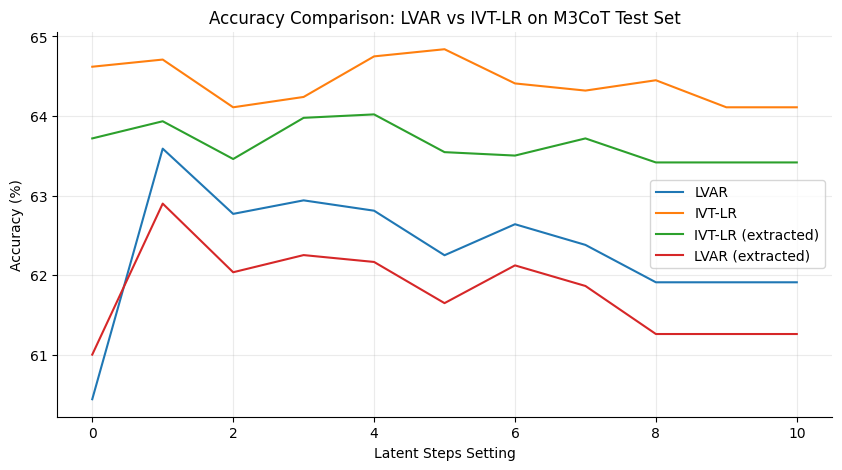

In [39]:
plt.plot(lvar_m3cot_test_accuracy["accuracy_pct"], label="LVAR")
plt.plot(ivtlr_m3cot_test_accuracy["accuracy_pct"], label="IVT-LR")
plt.plot(ivtlr_m3cot_test_latent_accuracy_extracted["accuracy_pct"], label="IVT-LR (extracted)")
plt.plot(lvar_m3cot_test_latent_accuracy_extracted["accuracy_pct"], label="LVAR (extracted)")
plt.title("Accuracy Comparison: LVAR vs IVT-LR on M3CoT Test Set")
plt.xlabel("Latent Steps Setting")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()

LVAR Oracle Summary:


,questions,oracle_correct,oracle_accuracy_pct,avg_correct_latent_steps_per_question
0,2318,1653,71.311475,6.79767


IVT-LR Oracle Summary:


,questions,oracle_correct,oracle_accuracy_pct,avg_correct_latent_steps_per_question
0,2318,1651,71.225194,7.001294


Text(0.5, 1.0, 'Oracle Accuracy Comparison: LVAR vs IVT-LR on M3CoT Test Set')

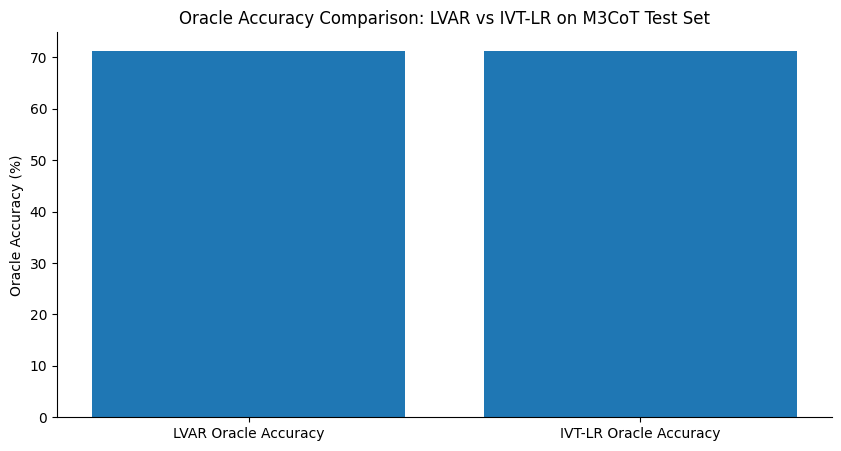

In [40]:
print("LVAR Oracle Summary:")
display(lvar_m3cot_test_oracle_summary)
print("IVT-LR Oracle Summary:")
display(ivtlr_m3cot_test_oracle_summary)
plt.bar(height=[lvar_m3cot_test_oracle_summary["oracle_accuracy_pct"].iloc[0], ivtlr_m3cot_test_oracle_summary["oracle_accuracy_pct"].iloc[0]], x=["LVAR Oracle Accuracy", "IVT-LR Oracle Accuracy"])
plt.grid(False)
plt.ylabel("Oracle Accuracy (%)")
plt.title("Oracle Accuracy Comparison: LVAR vs IVT-LR on M3CoT Test Set")


# M3CoT Validation Set

## IVT-LR

In [41]:
rows = []
for log_path in IVTLR_M3COT_VALIDATION.glob(f"*/{LOG_NAME}"):
    matches = list(FINAL_RESULT_RE.finditer(log_path.read_text(errors="replace")))
    if not matches:
        print(f"Warning: no [FINAL] result found in {log_path}")
        continue

    result = matches[-1].groupdict()
    rows.append(
        {
            "setting": log_path.parent.name,
            "total": int(result["total"]),
            "correct": int(result["correct"]),
            "accuracy_pct": float(result["accuracy"]),
        }
    )

if not rows:
    raise RuntimeError(f"No final accuracy results found under {IVTLR_M3COT_VALIDATION}")

ivtlr_m3cot_validation_accuracy = (
    pd.DataFrame(rows)
    .sort_values("setting", key=lambda column: column.map(setting_sort_key))
    .reset_index(drop=True)
)
display(
    ivtlr_m3cot_validation_accuracy.style
    .format({"accuracy_pct": "{:.2f}%"})
    .hide(axis="index")
)

setting,total,correct,accuracy_pct
original_ivtlr_latent_steps_0,1108,703,63.45%
original_ivtlr_latent_steps_1,1108,713,64.35%
original_ivtlr_latent_steps_10,1108,701,63.27%
original_ivtlr_latent_steps_2,1108,710,64.08%
original_ivtlr_latent_steps_3,1108,717,64.71%
original_ivtlr_latent_steps_4,1108,719,64.89%
original_ivtlr_latent_steps_5,1108,716,64.62%
original_ivtlr_latent_steps_6,1108,708,63.90%
original_ivtlr_latent_steps_7,1108,708,63.90%
original_ivtlr_latent_steps_8,1108,701,63.27%


In [42]:
M3COT_PREDICTIONS_NAME = "qwen_m3cot_predictions.jsonl"
EXPECTED_LATENT_STEPS = list(range(11))

m3cot_prediction_rows = []
m3cot_bad_prediction_rows = []

for prediction_path in sorted(IVTLR_M3COT_VALIDATION.glob(f"original_ivtlr_latent_steps_*/{M3COT_PREDICTIONS_NAME}")):
    setting = prediction_path.parent.name
    match = re.fullmatch(r"original_ivtlr_latent_steps_(\d+)", setting)
    if not match:
        continue

    latent_steps = int(match.group(1))
    if latent_steps not in EXPECTED_LATENT_STEPS:
        continue

    rows, bad_rows = load_jsonl(prediction_path)
    m3cot_bad_prediction_rows.extend(bad_rows)
    for row in rows:
        decoded_response = decoded_response_from_messages(row.get("messages"))
        gold_answer = normalize_answer(row.get("answer"))
        decoded_answer = extract_answer_from_response(decoded_response)
        m3cot_prediction_rows.append({
            "example_id": row.get("id") or row.get("example_id"),
            "latent_steps": latent_steps,
            "setting": setting,
            "domain": row.get("domain"),
            "topic": row.get("topic"),
            "gold_answer": gold_answer,
            "decoded_answer": decoded_answer,
            "correct": decoded_answer == gold_answer if gold_answer and decoded_answer else False,
            "question": row.get("messages", [None])[0] if row.get("messages") else None,
            "decoded_response": decoded_response,
            "prediction_path": str(prediction_path),
        })

ivtlr_m3cot_validation_predictions_extracted = pd.DataFrame(m3cot_prediction_rows)
if ivtlr_m3cot_validation_predictions_extracted.empty:
    raise RuntimeError(f"No fixed-step M3CoT prediction rows found under {IVTLR_M3COT_VALIDATION}")

missing_latent_steps = sorted(set(EXPECTED_LATENT_STEPS) - set(ivtlr_m3cot_validation_predictions_extracted["latent_steps"].unique()))
if missing_latent_steps:
    print(f"Warning: missing fixed latent-step prediction files for steps: {missing_latent_steps}")
if m3cot_bad_prediction_rows:
    print(f"Warning: {len(m3cot_bad_prediction_rows):,} malformed JSONL rows while loading M3CoT predictions")

ivtlr_m3cot_validation_latent_accuracy_extracted = (
    ivtlr_m3cot_validation_predictions_extracted
    .groupby(["latent_steps", "setting"], as_index=False)
    .agg(total=("example_id", "nunique"), correct=("correct", "sum"))
    .sort_values("latent_steps")
)
ivtlr_m3cot_validation_latent_accuracy_extracted["accuracy_pct"] = 100 * ivtlr_m3cot_validation_latent_accuracy_extracted["correct"] / ivtlr_m3cot_validation_latent_accuracy_extracted["total"]
display(ivtlr_m3cot_validation_latent_accuracy_extracted.style.format({"accuracy_pct": "{:.2f}%"}).hide(axis="index"))


latent_steps,setting,total,correct,accuracy_pct
0,original_ivtlr_latent_steps_0,1108,697,62.91%
1,original_ivtlr_latent_steps_1,1108,704,63.54%
2,original_ivtlr_latent_steps_2,1108,701,63.27%
3,original_ivtlr_latent_steps_3,1108,708,63.90%
4,original_ivtlr_latent_steps_4,1108,710,64.08%
5,original_ivtlr_latent_steps_5,1108,708,63.90%
6,original_ivtlr_latent_steps_6,1108,701,63.27%
7,original_ivtlr_latent_steps_7,1108,701,63.27%
8,original_ivtlr_latent_steps_8,1108,693,62.55%
9,original_ivtlr_latent_steps_9,1108,693,62.55%


In [43]:
oracle_rows = []
for example_id, group in ivtlr_m3cot_validation_predictions_extracted.groupby("example_id", dropna=False):
    group = group.sort_values("latent_steps")
    correct_steps = group.loc[group["correct"], "latent_steps"].astype(int).tolist()
    first = group.iloc[0]
    oracle_rows.append({
        "example_id": example_id,
        "domain": first.get("domain"),
        "topic": first.get("topic"),
        "gold_answer": first.get("gold_answer"),
        "oracle_correct": bool(correct_steps),
        "num_correct_latent_steps": len(correct_steps),
        "correct_latent_steps": correct_steps,
        "ideal_latent_steps": correct_steps[0] if correct_steps else np.nan,
        "question": first.get("question"),
    })

ivtlr_m3cot_validation_oracle_by_question = pd.DataFrame(oracle_rows).sort_values(["oracle_correct", "num_correct_latent_steps", "example_id"], ascending=[False, False, True])

correct_wide = (
    ivtlr_m3cot_validation_predictions_extracted
    .pivot_table(index="example_id", columns="latent_steps", values="correct", aggfunc="first")
    .rename(columns=lambda step: f"correct_at_step_{step}")
    .reset_index()
)
answer_wide = (
    ivtlr_m3cot_validation_predictions_extracted
    .pivot_table(index="example_id", columns="latent_steps", values="decoded_answer", aggfunc="first")
    .rename(columns=lambda step: f"answer_at_step_{step}")
    .reset_index()
)
ivtlr_m3cot_validation_oracle_by_question = ivtlr_m3cot_validation_oracle_by_question.merge(correct_wide, on="example_id", how="left").merge(answer_wide, on="example_id", how="left")

ivtlr_m3cot_validation_oracle_summary = pd.DataFrame([{
    "questions": ivtlr_m3cot_validation_oracle_by_question["example_id"].nunique(),
    "oracle_correct": int(ivtlr_m3cot_validation_oracle_by_question["oracle_correct"].sum()),
    "oracle_accuracy_pct": 100 * ivtlr_m3cot_validation_oracle_by_question["oracle_correct"].mean(),
    "avg_correct_latent_steps_per_question": ivtlr_m3cot_validation_oracle_by_question["num_correct_latent_steps"].mean(),
}])

display(ivtlr_m3cot_validation_oracle_summary.style.format({
    "oracle_accuracy_pct": "{:.2f}%",
    "avg_correct_latent_steps_per_question": "{:.2f}",
}).hide(axis="index"))

questions,oracle_correct,oracle_accuracy_pct,avg_correct_latent_steps_per_question
1108,782,70.58%,6.96


## LVAR

In [44]:
rows = []
for log_path in LVAR_M3COT_VALIDATION.glob(f"latent_steps*/{LOG_NAME}"):
    matches = list(FINAL_RESULT_RE.finditer(log_path.read_text(errors="replace")))
    if not matches:
        print(f"Warning: no [FINAL] result found in {log_path}")
        continue

    result = matches[-1].groupdict()
    rows.append(
        {
            "setting": log_path.parent.name,
            "total": int(result["total"]),
            "correct": int(result["correct"]),
            "accuracy_pct": float(result["accuracy"]),
        }
    )

if not rows:
    raise RuntimeError(f"No final accuracy results found under {LVAR_M3COT_VALIDATION}")

lvar_m3cot_validation_accuracy = (
    pd.DataFrame(rows)
    .sort_values("setting", key=lambda column: column.map(setting_sort_key))
    .reset_index(drop=True)
)
display(
    lvar_m3cot_validation_accuracy.style
    .format({"accuracy_pct": "{:.2f}%"})
    .hide(axis="index")
)

setting,total,correct,accuracy_pct
latent_steps_0,1108,649,58.57%
latent_steps_1,1108,671,60.56%
latent_steps_2,1108,679,61.28%
latent_steps_3,1108,675,60.92%
latent_steps_4,1108,672,60.65%
latent_steps_5,1108,668,60.29%
latent_steps_6,1108,673,60.74%
latent_steps_7,1108,663,59.84%
latent_steps_8,1108,651,58.75%
latent_steps_9,1108,651,58.75%


In [45]:
M3COT_PREDICTIONS_NAME = "qwen_m3cot_predictions.jsonl"
EXPECTED_LATENT_STEPS = list(range(11))

m3cot_prediction_rows = []
m3cot_bad_prediction_rows = []

for prediction_path in sorted(LVAR_M3COT_VALIDATION.glob(f"latent_steps*/{M3COT_PREDICTIONS_NAME}")):
    setting = prediction_path.parent.name
    match = re.fullmatch(r"latent_steps_(\d+)", setting)
    if not match:
        continue

    latent_steps = int(match.group(1))
    if latent_steps not in EXPECTED_LATENT_STEPS:
        continue

    rows, bad_rows = load_jsonl(prediction_path)
    m3cot_bad_prediction_rows.extend(bad_rows)
    for row in rows:
        decoded_response = decoded_response_from_messages(row.get("messages"))
        gold_answer = normalize_answer(row.get("answer"))
        decoded_answer = extract_answer_from_response(decoded_response)
        m3cot_prediction_rows.append({
            "example_id": row.get("id") or row.get("example_id"),
            "latent_steps": latent_steps,
            "setting": setting,
            "domain": row.get("domain"),
            "topic": row.get("topic"),
            "gold_answer": gold_answer,
            "decoded_answer": decoded_answer,
            "correct": decoded_answer == gold_answer if gold_answer and decoded_answer else False,
            "question": row.get("messages", [None])[0] if row.get("messages") else None,
            "decoded_response": decoded_response,
            "prediction_path": str(prediction_path),
        })

lvar_m3cot_validation_predictions_extracted = pd.DataFrame(m3cot_prediction_rows)
if lvar_m3cot_validation_predictions_extracted.empty:
    raise RuntimeError(f"No fixed-step M3CoT prediction rows found under {LVAR_M3COT_VALIDATION}")

missing_latent_steps = sorted(set(EXPECTED_LATENT_STEPS) - set(lvar_m3cot_validation_predictions_extracted["latent_steps"].unique()))
if missing_latent_steps:
    print(f"Warning: missing fixed latent-step prediction files for steps: {missing_latent_steps}")
if m3cot_bad_prediction_rows:
    print(f"Warning: {len(m3cot_bad_prediction_rows):,} malformed JSONL rows while loading M3CoT predictions")

lvar_m3cot_validation_latent_accuracy_extracted = (
    lvar_m3cot_validation_predictions_extracted
    .groupby(["latent_steps", "setting"], as_index=False)
    .agg(total=("example_id", "nunique"), correct=("correct", "sum"))
    .sort_values("latent_steps")
)
lvar_m3cot_validation_latent_accuracy_extracted["accuracy_pct"] = 100 * lvar_m3cot_validation_latent_accuracy_extracted["correct"] / lvar_m3cot_validation_latent_accuracy_extracted["total"]
display(lvar_m3cot_validation_latent_accuracy_extracted.style.format({"accuracy_pct": "{:.2f}%"}).hide(axis="index"))


latent_steps,setting,total,correct,accuracy_pct
0,latent_steps_0,1108,648,58.48%
1,latent_steps_1,1108,664,59.93%
2,latent_steps_2,1108,672,60.65%
3,latent_steps_3,1108,670,60.47%
4,latent_steps_4,1108,667,60.20%
5,latent_steps_5,1108,662,59.75%
6,latent_steps_6,1108,668,60.29%
7,latent_steps_7,1108,658,59.39%
8,latent_steps_8,1108,646,58.30%
9,latent_steps_9,1108,646,58.30%


In [46]:
oracle_rows = []
for example_id, group in lvar_m3cot_validation_predictions_extracted.groupby("example_id", dropna=False):
    group = group.sort_values("latent_steps")
    correct_steps = group.loc[group["correct"], "latent_steps"].astype(int).tolist()
    first = group.iloc[0]
    oracle_rows.append({
        "example_id": example_id,
        "domain": first.get("domain"),
        "topic": first.get("topic"),
        "gold_answer": first.get("gold_answer"),
        "oracle_correct": bool(correct_steps),
        "num_correct_latent_steps": len(correct_steps),
        "correct_latent_steps": correct_steps,
        "ideal_latent_steps": correct_steps[0] if correct_steps else np.nan,
        "question": first.get("question"),
    })

lvar_m3cot_validation_oracle_by_question = pd.DataFrame(oracle_rows).sort_values(["oracle_correct", "num_correct_latent_steps", "example_id"], ascending=[False, False, True])

correct_wide = (
    lvar_m3cot_validation_predictions_extracted
    .pivot_table(index="example_id", columns="latent_steps", values="correct", aggfunc="first")
    .rename(columns=lambda step: f"correct_at_step_{step}")
    .reset_index()
)
answer_wide = (
    lvar_m3cot_validation_predictions_extracted
    .pivot_table(index="example_id", columns="latent_steps", values="decoded_answer", aggfunc="first")
    .rename(columns=lambda step: f"answer_at_step_{step}")
    .reset_index()
)
lvar_m3cot_validation_oracle_by_question = lvar_m3cot_validation_oracle_by_question.merge(correct_wide, on="example_id", how="left").merge(answer_wide, on="example_id", how="left")

lvar_m3cot_validation_oracle_summary = pd.DataFrame([{
    "questions": lvar_m3cot_validation_oracle_by_question["example_id"].nunique(),
    "oracle_correct": int(lvar_m3cot_validation_oracle_by_question["oracle_correct"].sum()),
    "oracle_accuracy_pct": 100 * lvar_m3cot_validation_oracle_by_question["oracle_correct"].mean(),
    "avg_correct_latent_steps_per_question": lvar_m3cot_validation_oracle_by_question["num_correct_latent_steps"].mean(),
}])

display(lvar_m3cot_validation_oracle_summary.style.format({
    "oracle_accuracy_pct": "{:.2f}%",
    "avg_correct_latent_steps_per_question": "{:.2f}",
}).hide(axis="index"))

questions,oracle_correct,oracle_accuracy_pct,avg_correct_latent_steps_per_question
1108,755,68.14%,6.54


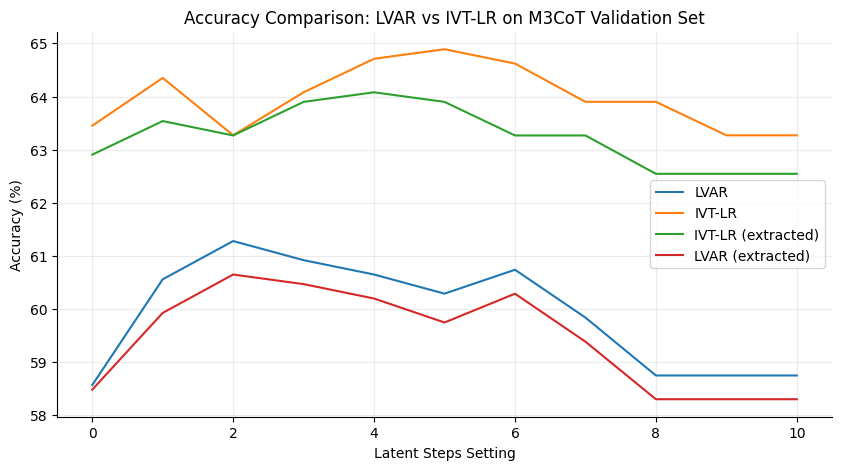

In [47]:
plt.plot(lvar_m3cot_validation_accuracy["accuracy_pct"], label="LVAR")
plt.plot(ivtlr_m3cot_validation_accuracy["accuracy_pct"], label="IVT-LR")
plt.plot(ivtlr_m3cot_validation_latent_accuracy_extracted["accuracy_pct"], label="IVT-LR (extracted)")
plt.plot(lvar_m3cot_validation_latent_accuracy_extracted["accuracy_pct"], label="LVAR (extracted)")
plt.title("Accuracy Comparison: LVAR vs IVT-LR on M3CoT Validation Set")
plt.xlabel("Latent Steps Setting")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()

LVAR Oracle Summary:


,questions,oracle_correct,oracle_accuracy_pct,avg_correct_latent_steps_per_question
0,1108,755,68.140794,6.540614


IVT-LR Oracle Summary:


,questions,oracle_correct,oracle_accuracy_pct,avg_correct_latent_steps_per_question
0,1108,782,70.577617,6.957581


Text(0.5, 1.0, 'Oracle Accuracy Comparison: LVAR vs IVT-LR on M3CoT Validation Set')

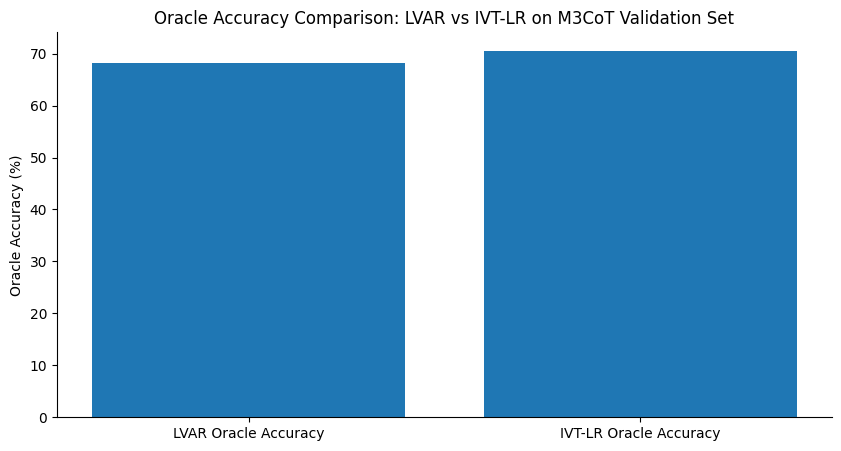

In [48]:
print("LVAR Oracle Summary:")
display(lvar_m3cot_validation_oracle_summary)
print("IVT-LR Oracle Summary:")
display(ivtlr_m3cot_validation_oracle_summary)
plt.bar(height=[lvar_m3cot_validation_oracle_summary["oracle_accuracy_pct"].iloc[0], ivtlr_m3cot_validation_oracle_summary["oracle_accuracy_pct"].iloc[0]], x=["LVAR Oracle Accuracy", "IVT-LR Oracle Accuracy"])
plt.grid(False)
plt.ylabel("Oracle Accuracy (%)")
plt.title("Oracle Accuracy Comparison: LVAR vs IVT-LR on M3CoT Validation Set")


# SQA Test Set

## IVT-LR

In [49]:
rows = []
for log_path in IVTLR_SQA_TEST.glob(f"*/{SQA_LOG_NAME}"):
    matches = list(FINAL_RESULT_RE.finditer(log_path.read_text(errors="replace")))
    if not matches:
        print(f"Warning: no [FINAL] result found in {log_path}")
        continue

    result = matches[-1].groupdict()
    rows.append(
        {
            "setting": log_path.parent.name,
            "total": int(result["total"]),
            "correct": int(result["correct"]),
            "accuracy_pct": float(result["accuracy"]),
        }
    )

if not rows:
    raise RuntimeError(f"No final accuracy results found under {IVTLR_SQA_TEST}")

ivtlr_sqa_test_accuracy = (
    pd.DataFrame(rows)
    .sort_values("setting", key=lambda column: column.map(setting_sort_key))
    .reset_index(drop=True)
)
display(
    ivtlr_sqa_test_accuracy.style
    .format({"accuracy_pct": "{:.2f}%"})
    .hide(axis="index")
)

setting,total,correct,accuracy_pct
original_ivtlr_latent_steps_0,2017,1859,92.17%
original_ivtlr_latent_steps_1,2017,1864,92.41%
original_ivtlr_latent_steps_10,2017,1846,91.52%
original_ivtlr_latent_steps_2,2017,1853,91.87%
original_ivtlr_latent_steps_3,2017,1861,92.27%
original_ivtlr_latent_steps_4,2017,1855,91.97%
original_ivtlr_latent_steps_5,2017,1863,92.36%
original_ivtlr_latent_steps_6,2017,1858,92.12%
original_ivtlr_latent_steps_7,2017,1848,91.62%
original_ivtlr_latent_steps_8,2017,1846,91.52%


## LVAR

In [50]:
rows = []
for log_path in LVAR_SQA_TEST.glob(f"*/{SQA_LOG_NAME}"):
    matches = list(FINAL_RESULT_RE.finditer(log_path.read_text(errors="replace")))
    if not matches:
        print(f"Warning: no [FINAL] result found in {log_path}")
        continue

    result = matches[-1].groupdict()
    rows.append(
        {
            "setting": log_path.parent.name,
            "total": int(result["total"]),
            "correct": int(result["correct"]),
            "accuracy_pct": float(result["accuracy"]),
        }
    )

if not rows:
    raise RuntimeError(f"No final accuracy results found under {LVAR_SQA_TEST}")

lvar_sqa_test_accuracy = (
    pd.DataFrame(rows)
    .sort_values("setting", key=lambda column: column.map(setting_sort_key))
    .reset_index(drop=True)
)
display(
    lvar_sqa_test_accuracy.style
    .format({"accuracy_pct": "{:.2f}%"})
    .hide(axis="index")
)

setting,total,correct,accuracy_pct
latent_steps_0,2017,1843,91.37%
latent_steps_1,2017,1842,91.32%
latent_steps_2,2017,1844,91.42%
latent_steps_3,2017,1842,91.32%
latent_steps_4,2017,1840,91.22%
latent_steps_5,2017,1838,91.13%
latent_steps_6,2017,1835,90.98%
latent_steps_7,2017,1823,90.38%
latent_steps_8,2017,1818,90.13%
latent_steps_9,2017,1818,90.13%


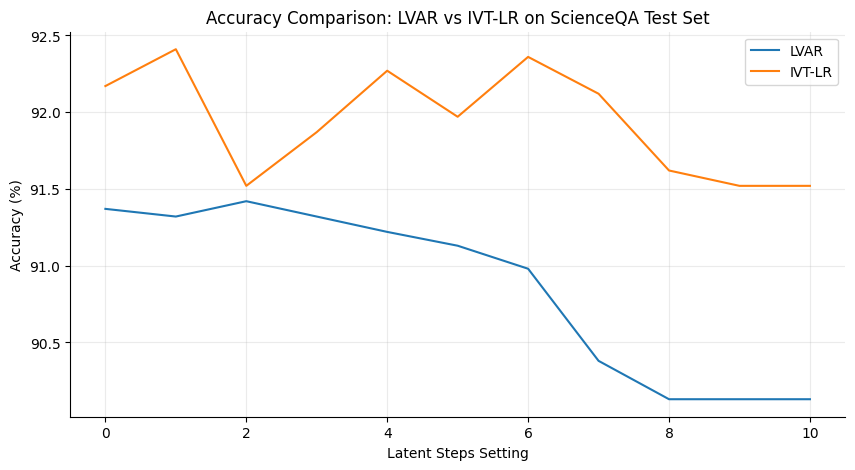

In [51]:
plt.plot(lvar_sqa_test_accuracy["accuracy_pct"], label="LVAR")
plt.plot(ivtlr_sqa_test_accuracy["accuracy_pct"], label="IVT-LR")
plt.title("Accuracy Comparison: LVAR vs IVT-LR on ScienceQA Test Set")
plt.xlabel("Latent Steps Setting")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()

# SQA Validation Set

## IVT-LR

In [52]:
rows = []
for log_path in IVTLR_SQA_VALIDATION.glob(f"*/{SQA_LOG_NAME}"):
    matches = list(FINAL_RESULT_RE.finditer(log_path.read_text(errors="replace")))
    if not matches:
        print(f"Warning: no [FINAL] result found in {log_path}")
        continue

    result = matches[-1].groupdict()
    rows.append(
        {
            "setting": log_path.parent.name,
            "total": int(result["total"]),
            "correct": int(result["correct"]),
            "accuracy_pct": float(result["accuracy"]),
        }
    )

if not rows:
    raise RuntimeError(f"No final accuracy results found under {IVTLR_SQA_VALIDATION}")

ivtlr_sqa_validation_accuracy = (
    pd.DataFrame(rows)
    .sort_values("setting", key=lambda column: column.map(setting_sort_key))
    .reset_index(drop=True)
)
display(
    ivtlr_sqa_validation_accuracy.style
    .format({"accuracy_pct": "{:.2f}%"})
    .hide(axis="index")
)

setting,total,correct,accuracy_pct
original_ivtlr_latent_steps_0,2097,1873,89.32%
original_ivtlr_latent_steps_1,2097,1877,89.51%
original_ivtlr_latent_steps_10,2097,1848,88.13%
original_ivtlr_latent_steps_2,2097,1877,89.51%
original_ivtlr_latent_steps_3,2097,1880,89.65%
original_ivtlr_latent_steps_4,2097,1876,89.46%
original_ivtlr_latent_steps_5,2097,1878,89.56%
original_ivtlr_latent_steps_6,2097,1861,88.75%
original_ivtlr_latent_steps_7,2097,1858,88.60%
original_ivtlr_latent_steps_8,2097,1848,88.13%


## LVAR

In [53]:
rows = []
for log_path in LVAR_SQA_VALIDATION.glob(f"*/{SQA_LOG_NAME}"):
    matches = list(FINAL_RESULT_RE.finditer(log_path.read_text(errors="replace")))
    if not matches:
        print(f"Warning: no [FINAL] result found in {log_path}")
        continue

    result = matches[-1].groupdict()
    rows.append(
        {
            "setting": log_path.parent.name,
            "total": int(result["total"]),
            "correct": int(result["correct"]),
            "accuracy_pct": float(result["accuracy"]),
        }
    )

if not rows:
    raise RuntimeError(f"No final accuracy results found under {LVAR_SQA_VALIDATION}")

lvar_sqa_validation_accuracy = (
    pd.DataFrame(rows)
    .sort_values("setting", key=lambda column: column.map(setting_sort_key))
    .reset_index(drop=True)
)
display(
    lvar_sqa_validation_accuracy.style
    .format({"accuracy_pct": "{:.2f}%"})
    .hide(axis="index")
)

setting,total,correct,accuracy_pct
latent_steps_0,2097,1886,89.94%
latent_steps_1,2097,1892,90.22%
latent_steps_2,2097,1889,90.08%
latent_steps_3,2097,1892,90.22%
latent_steps_4,2097,1896,90.41%
latent_steps_5,2097,1893,90.27%
latent_steps_6,2097,1895,90.37%


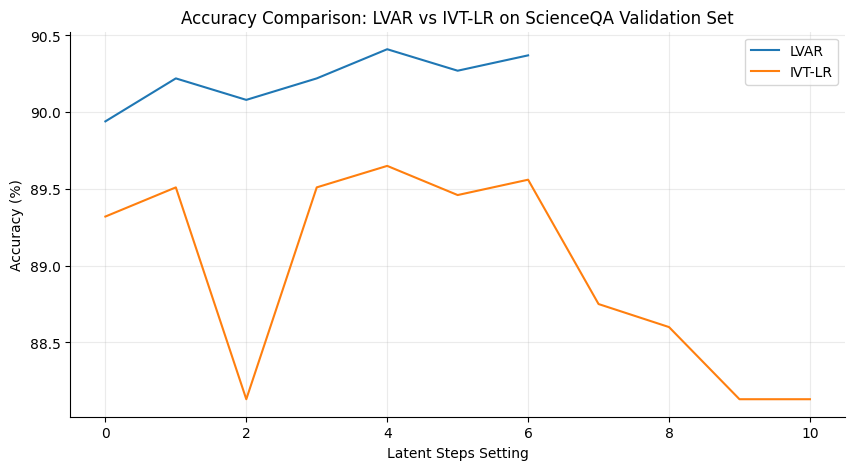

In [54]:
plt.plot(lvar_sqa_validation_accuracy["accuracy_pct"], label="LVAR")
plt.plot(ivtlr_sqa_validation_accuracy["accuracy_pct"], label="IVT-LR")
plt.title("Accuracy Comparison: LVAR vs IVT-LR on ScienceQA Validation Set")
plt.xlabel("Latent Steps Setting")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()